# Domain adaptation

To achieve optimal classification performance for our target dataset, we need to adapt classifiers trained on different data to our target. For this, we need annotated data from our target domain. Training for domain adaptation can then be achieved in two ways:

* Multi-task learning (MTL): two or more tasks, i.e. the target task and the support task(s) are trained in parallel by sharing the same base transformer model parameters
* Intermediate fine-tuning: First, we train a classifier on the support task, then further fine-tune it on the target task.

For evaluation, we also need labeled data from the target domain.

[Weller et al. (2022)](https://aclanthology.org/2022.acl-short.30/) propose "a simple heuristic for when to use one of these techniques over the other: pairwise MTL is better than STILTs when the target task has fewer instances than the supporting task and vice versa."

Actually this would call for MTL in our case. But since MTL is slightly more complicated to implement, we stick to intermediate fine-tuning in this tutorial.

## Annotate target data

In the last tutorial, we created a sample of 300 tweets from the CCS dataset. Let us collaboratively annotate this dataset using a simple annotator tool:

[annotatoR on shinyapps.io](https://gregor-w.shinyapps.io/annotator/) - Click here for joining our annotation project.

[annotatoR on GitHub](https://github.com/Leibniz-HBI/annotatoR)

We code offensive language in German as defined by this codebook:
[Guidelines for IGGSA Shared Task on the Identification of Offensive Language](https://www.coli.uni-saarland.de/~miwieg/Germeval/guidelines-iggsa-shared.pdf)


# Intermediate fine-tuning



Mount the Google Drive. Change the folder name to your specific name!

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/TU-Ilmenau-Workshop

Mounted at /content/gdrive
/content/gdrive/MyDrive/TU-Ilmenau-Workshop


We create a training/test dataset for further fine-tuning based on our annotated data.

In [2]:
import pandas as pd

annotated_samples = pd.read_csv("annotations-2024-11-18(2).csv") # upload the new file and modify this filename accordingly
annotated_samples

,id,text,username,label
0,1596465159127846912,Die Debatte um die #LetzteGeneration ist völli...,Wendo,other
1,1540271664692428800,Green washing is a climate killer end fossil f...,Wendo,other
2,1596465159127846912,Die Debatte um die #LetzteGeneration ist völli...,maxz,other
3,1540271664692428800,Green washing is a climate killer end fossil f...,maxz,other
4,1596465159127846912,Die Debatte um die #LetzteGeneration ist völli...,Marius,other
...,...,...,...,...
237,1487046550098522112,TW: Gewalt\nEine junge Frau wird von einem Aut...,DL,other
238,1487046550098522112,TW: Gewalt\nEine junge Frau wird von einem Aut...,Jingyuan,other
239,1487046550098522112,TW: Gewalt\nEine junge Frau wird von einem Aut...,Ro,offense
240,1487046550098522112,TW: Gewalt\nEine junge Frau wird von einem Aut...,ED,other


from matplotlib import pyplot as plt
annotated_samples['id'].plot(kind='hist', bins=20, title='id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
annotated_samples.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
annotated_samples['id'].plot(kind='line', figsize=(8, 4), title='id')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(annotated_samples['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(annotated_samples, x='id', y='label', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

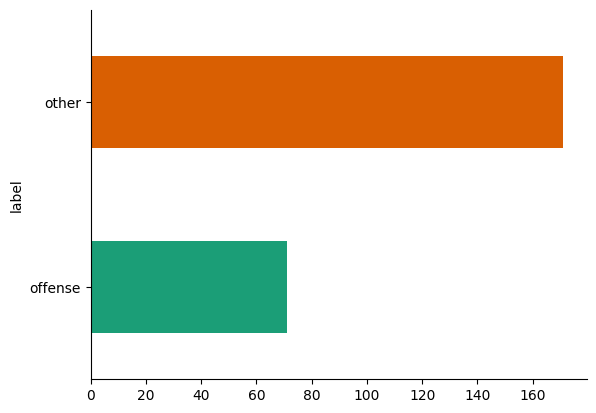

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns
annotated_samples.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

### Intercoder agreement
Okay, we need some data wrangling to create the right format for a computation of Krippendorff's alpha metric.

It expects a 2D numpy array with rows as documents and cols as raters/coders.

In [4]:
import pandas as pd
import numpy as np

# Extract unique usernames
unique_usernames = annotated_samples["username"].unique()

# Create an empty DataFrame with IDs as index and usernames as columns
result_df = pd.DataFrame(index=annotated_samples["id"].unique(), columns=unique_usernames)
result_df = result_df.astype(object)  # Allow for np.nan values

# Fill the DataFrame with label values
for index, row in annotated_samples.iterrows():
    result_df.loc[row["id"], row["username"]] = row["label"]

# Replace missing values with np.nan
kripp_df = result_df.fillna(np.nan)
kripp_df

,Wendo,maxz,Marius,MaxS,EH,immanuel,ED,ahmad.mak,Jingyuan,DL,Lisa,gregor,Ro,Anastasiia Shevts
1596465159127846912,other,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1540271664692428800,other,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1592853018113765376,other,other,NaN,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1584233303460040704,other,other,NaN,NaN,offense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1599897696030101504,other,other,NaN,NaN,offense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1602457883358134272,NaN,offense,offense,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1584470250506321920,NaN,other,offense,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1593584785628200960,NaN,other,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1595856802809249792,NaN,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other,NaN,NaN,NaN


The library `krippendorff` contains all functions we need to calculate the IRR (https://pypi.org/project/krippendorff/).

In [5]:
!pip install krippendorff

import pandas as pd
import krippendorff
import numpy as np

# for the alpha function we convert the data frame to a numpy array of string
# values
kripp_array = kripp_df.values.astype(str)

# here the metric is computed.
alpha = krippendorff.alpha(reliability_data=kripp_array, level_of_measurement='nominal')

print(f"Krippendorff's alpha: {alpha}")

Krippendorff's alpha: 0.11921365323165645


There is probabibly room for improvement of the intercoder reliability by more coder training and iterations for discussion of edge cases.

For the moment, we will use all examples with a clear majority decision for our training and test data.

In [22]:
# prompt: Using the irrCac packge, calculate gwet's AC on the kripp_array

!pip install irrCAC

import irrCAC

# Assuming kripp_array is defined as in your provided code
# kripp_array = kripp_df.values.astype(str)

gwet_ac = irrCAC.gwet.AC(kripp_array)

print(f"Gwet's AC: {gwet_ac}")

AttributeError: module 'irrCAC' has no attribute 'gwet'

In [24]:
gwet_ac = irrCAC.gwet_ac(kripp_array)

print(f"Gwet's AC: {gwet_ac}")

AttributeError: module 'irrCAC' has no attribute 'gwet_ac'

,Wendo,maxz,Marius,MaxS,EH,immanuel,ED,ahmad.mak,Jingyuan,DL,Lisa,gregor,Ro,Anastasiia Shevts,majority
1596465159127846912,other,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other
1540271664692428800,other,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other
1592853018113765376,other,other,NaN,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other
1584233303460040704,other,other,NaN,NaN,offense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other
1599897696030101504,other,other,NaN,NaN,offense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1602457883358134272,NaN,offense,offense,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,offense
1584470250506321920,NaN,other,offense,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other
1593584785628200960,NaN,other,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other
1595856802809249792,NaN,other,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,other,NaN,NaN,NaN,other


from matplotlib import pyplot as plt
import seaborn as sns
filtered_kripp_df.groupby('Wendo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
filtered_kripp_df.groupby('maxz').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
filtered_kripp_df.groupby('Marius').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
filtered_kripp_df.groupby('MaxS').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['maxz'].value_counts()
    for x_label, grp in filtered_kripp_df.groupby('Wendo')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Wendo')
_ = plt.ylabel('maxz')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Marius'].value_counts()
    for x_label, grp in filtered_kripp_df.groupby('maxz')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('maxz')
_ = plt.ylabel('Marius')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['MaxS'].value_counts()
    for x_label, grp in filtered_kripp_df.groupby('Marius')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Marius')
_ = plt.ylabel('MaxS')

ValueError: zero-size array to reduction operation fmin which has no identity

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['EH'].value_counts()
    for x_label, grp in filtered_kripp_df.groupby('MaxS')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('MaxS')
_ = plt.ylabel('EH')

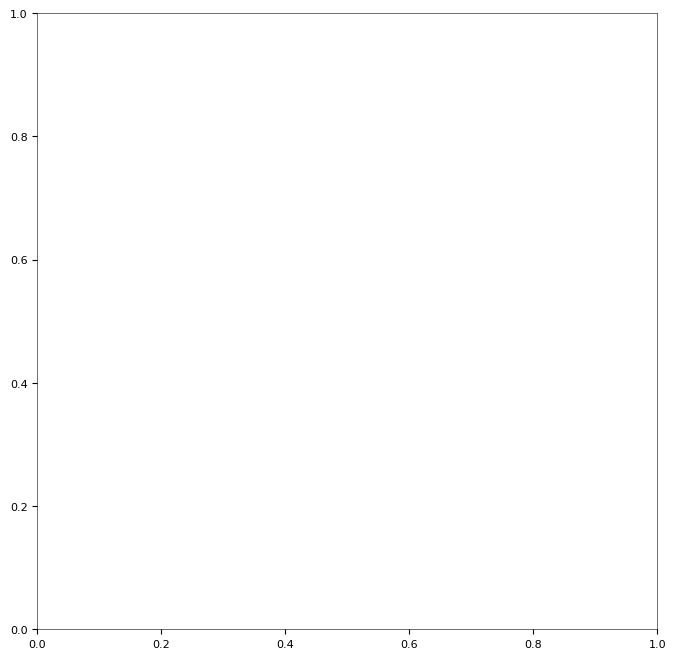

In [6]:
# Find the majority value for each row in kripp_df
majority_values = []
for index, row in kripp_df.iterrows():
    value_counts = row.value_counts()
    if value_counts.max() > len(row.dropna()) / 2:  # Check if a majority exists
        majority_values.append(value_counts.idxmax())
    else:
        majority_values.append(np.nan)  # No clear majority

# Filter rows with no clear majority (NaN) and construct a new DataFrame
filtered_kripp_df = kripp_df.copy()
filtered_kripp_df['majority'] = majority_values
filtered_kripp_df = filtered_kripp_df.dropna(subset=['majority'])

# Display or use the filtered DataFrame
filtered_kripp_df

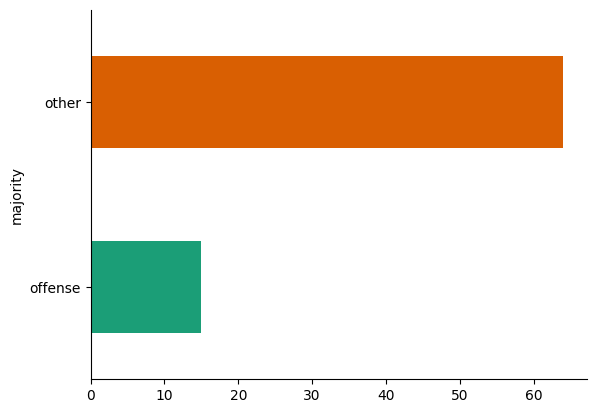

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns
filtered_kripp_df.groupby('majority').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

Create a filtered data frame that contains our final training data.

In [8]:
# Reset the index of filtered_kripp_df to make 'id' a regular column
filtered_kripp_df = filtered_kripp_df.reset_index().rename(columns={'index': 'id', 'majority': 'label'})  # Rename the index column to 'id'
filtered_kripp_df = filtered_kripp_df[['id', 'label']]

# Merge the two dataframes based on the 'id' column
merged_df = pd.merge(filtered_kripp_df, annotated_samples[['id', 'text']].drop_duplicates(), on='id', how='left')

# Now merged_df contains the 'text' column from annotated_samples joined with the corresponding rows in filtered_kripp_df
merged_df

,id,label,text
0,1596465159127846912,other,Die Debatte um die #LetzteGeneration ist völli...
1,1540271664692428800,other,Green washing is a climate killer end fossil f...
2,1592853018113765376,other,"Krass, wie haushoch @AimeevanBaalen, die Sprec..."
3,1584233303460040704,other,"""Die Gesellschaft"" hält Euch nur leider für zi..."
4,1599897696030101504,other,"Krass:\nEs scheint, als wurden Rettungskräfte ..."
...,...,...,...
74,1602457883358134272,offense,@sapereaudeHH @ybessal @AufstandLastGen Bitte....
75,1584470250506321920,other,@Silver77782523 @Purzel1961 @AufstandLastGen H...
76,1593584785628200960,other,@PHoefig @AufstandLastGen @ClimateHuman @Scien...
77,1595856802809249792,other,Mir fehlen da ja echt die Worte. \n\n- Es gibt...


We create a train, dev, test set split from our annotated data

In [15]:
# prompt: In merged_df, the values in the column label should be uppercase

# Convert the 'label' column to uppercase
merged_df['label'] = merged_df['label'].str.upper()

# Now the 'label' column in merged_df has uppercase values

In [16]:
from sklearn.model_selection import train_test_split
from pathlib import Path

# train_test_split works also with pandas dataframes
df_train, df_test = train_test_split(merged_df, test_size=0.2, random_state=1)
df_train, df_dev = train_test_split(df_train, test_size=0.1, random_state=1)

# export as falir csv corpus
path = "flair_ccs_corpus"
Path(path).mkdir(exist_ok = True)
df_train.to_csv(path + "/train.csv", sep="\t")
df_dev.to_csv(path + "/dev.csv", sep="\t")
df_test.to_csv(path + "/test.csv", sep="\t")

In [10]:
# load flair (and install first, if it is not present)
try:
  import flair
except:
  !pip install flair
  import flair

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.5/776.5 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.6/82.6 kB 8.6 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=1541f47d2a81b47599cca50edbef185a7b625b89f68f48266392edf9a97816a6
  Stored in directory: /root/.cac

We can now load the newly created CSV corpus. Notice that we have different column indexes here (text in the 3rd column, label in the 2nd) compared to our GermEval OLD corpus.

In [17]:
from flair.datasets import CSVClassificationCorpus
corpus = CSVClassificationCorpus("flair_ccs_corpus/",
  {3: "text", 2: "label"},
  skip_header=True,
  label_type="OLD",
  delimiter='\t'
)

2024-11-18 10:39:39,014 Reading data from flair_ccs_corpus
2024-11-18 10:39:39,016 Train: flair_ccs_corpus/train.csv
2024-11-18 10:39:39,019 Dev: flair_ccs_corpus/dev.csv
2024-11-18 10:39:39,020 Test: flair_ccs_corpus/test.csv


In [18]:
print(corpus.obtain_statistics())

{
    "TRAIN": {
        "dataset": "TRAIN",
        "total_number_of_documents": 56,
        "number_of_documents_per_class": {
            "OTHER": 46,
            "OFFENSE": 10
        },
        "number_of_tokens_per_tag": {},
        "number_of_tokens": {
            "total": 1989,
            "min": 4,
            "max": 66,
            "avg": 35.517857142857146
        }
    },
    "TEST": {
        "dataset": "TEST",
        "total_number_of_documents": 16,
        "number_of_documents_per_class": {
            "OTHER": 12,
            "OFFENSE": 4
        },
        "number_of_tokens_per_tag": {},
        "number_of_tokens": {
            "total": 617,
            "min": 7,
            "max": 81,
            "avg": 38.5625
        }
    },
    "DEV": {
        "dataset": "DEV",
        "total_number_of_documents": 7,
        "number_of_documents_per_class": {
            "OTHER": 6,
            "OFFENSE": 1
        },
        "number_of_tokens_per_tag": {},
        "number_of_

We load the best model from the training process in the previous tutorial.

In [13]:
from flair.trainers import ModelTrainer
from flair.embeddings import TransformerDocumentEmbeddings
from flair.models import TextClassifier

# load best model from previous training run
classifier = TextClassifier.load('flair_models/old/best-model.pt')

Get a baseline: How does this GermEval OLD trained classifier perform on our Twitter climate protest data?

In [19]:
# now let's evaluate it on our newly annotated test set
res = classifier.evaluate(corpus.test, gold_label_type="OLD")
print(res)

100%|██████████| 1/1 [00:00<00:00,  3.51it/s]


Results:
- F-score (micro) 0.6875
- F-score (macro) 0.5429
- Accuracy 0.6875

By class:
              precision    recall  f1-score   support

       OTHER     0.7692    0.8333    0.8000        12
     OFFENSE     0.3333    0.2500    0.2857         4

    accuracy                         0.6875        16
   macro avg     0.5513    0.5417    0.5429        16
weighted avg     0.6603    0.6875    0.6714        16

Loss: 0.7957341074943542'


Can we improve this performance by further fine-tuning on our in-domain target data?

In [20]:
# create a trainer object
trainer = ModelTrainer(classifier, corpus) # .downsample(0.2)

# run fine tuning (on the GPU!)
res = trainer.fine_tune(
    'flair_models/old_ccs',
    learning_rate=5e-6,
    mini_batch_size=8,
    warmup_fraction=0.1,
    train_with_dev=False,
    max_epochs=4,
    main_evaluation_metric = ("macro avg", 'f1-score'),
    use_final_model_for_eval = False,
    save_final_model = False,
    #write_weights = False,
    #epoch = self.epochs_trained
)
print(res)

2024-11-18 10:41:12,571 ----------------------------------------------------------------------------------------------------
2024-11-18 10:41:12,574 Model: "TextClassifier(
  (embeddings): TransformerDocumentEmbeddings(
    (model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(31103, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                

/usr/local/lib/python3.10/dist-packages/flair/trainers/trainer.py:499: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and flair.device.type != "cpu")


2024-11-18 10:41:13,396 epoch 1 - iter 1/7 - loss 1.29782856 - time (sec): 0.78 - samples/sec: 10.30 - lr: 0.000000 - momentum: 0.000000
2024-11-18 10:41:13,509 epoch 1 - iter 2/7 - loss 1.26898998 - time (sec): 0.89 - samples/sec: 17.99 - lr: 0.000002 - momentum: 0.000000
2024-11-18 10:41:13,726 epoch 1 - iter 3/7 - loss 1.30251539 - time (sec): 1.11 - samples/sec: 21.69 - lr: 0.000003 - momentum: 0.000000
2024-11-18 10:41:13,920 epoch 1 - iter 4/7 - loss 1.00683993 - time (sec): 1.30 - samples/sec: 24.61 - lr: 0.000005 - momentum: 0.000000
2024-11-18 10:41:14,094 epoch 1 - iter 5/7 - loss 0.88494517 - time (sec): 1.47 - samples/sec: 27.13 - lr: 0.000005 - momentum: 0.000000
2024-11-18 10:41:14,238 epoch 1 - iter 6/7 - loss 0.86569541 - time (sec): 1.62 - samples/sec: 29.66 - lr: 0.000005 - momentum: 0.000000
2024-11-18 10:41:14,373 epoch 1 - iter 7/7 - loss 0.93302151 - time (sec): 1.75 - samples/sec: 31.94 - lr: 0.000004 - momentum: 0.000000
2024-11-18 10:41:14,376 -----------------

100%|██████████| 1/1 [00:00<00:00,  7.44it/s]

2024-11-18 10:41:14,541 DEV : loss 0.9242868423461914 - f1-score (macro avg)  0.4615
2024-11-18 10:41:14,555 saving best model


...

100%|██████████| 1/1 [00:00<00:00,  9.22it/s]

2024-11-18 10:41:21,172 DEV : loss 0.9199491739273071 - f1-score (macro avg)  0.4615
2024-11-18 10:41:21,190 ----------------------------------------------------------------------------------------------------


2024-11-18 10:41:21,276 Loading model from best epoch ...


100%|██████████| 1/1 [00:00<00:00,  4.31it/s]

2024-11-18 10:41:28,178 
Results:
- F-score (micro) 0.75
- F-score (macro) 0.5897
- Accuracy 0.75

By class:
              precision    recall  f1-score   support

       OTHER     0.7857    0.9167    0.8462        12
     OFFENSE     0.5000    0.2500    0.3333         4

    accuracy                         0.7500        16
   macro avg     0.6429    0.5833    0.5897        16
weighted avg     0.7143    0.7500    0.7179        16

2024-11-18 10:41:28,180 ----------------------------------------------------------------------------------------------------
{'test_score': 0.5897435897435898}


If everything went well, and we did carefully annotate our Twitter climate protest data, we should see a noteworthy improvement in our evaluation metrics.